# Lesson 1: Token economics and cost forecasting

*Module 1 · about 10 minutes · API key optional (only the last section calls a model)*

Most conversations about LLM cost start with the price per million tokens. That's the wrong place to start. In this notebook we'll look at the three things that actually decide what you pay: how many tokens your text turns into, which model you send it to, and how many times the same tokens get processed before a user sees an answer.

By the end you should be able to:

1. Explain why two prompts that mean the same thing can cost very different amounts.
2. Work out the price gap between the cheapest and most expensive model for exactly the same workload (it's about 107× on our rate card).
3. Build a monthly forecast per *completed task*, with the multipliers that matter: agent steps, cache hits, and retries.


### A little background first

A **token** is the unit a model reads and writes. It's usually a word or a piece of a word. Common English words are often one token each, while rare words, numbers, and codes get split into several. The model never sees your characters, only the token IDs, and you pay per token.

You pay separately for **input** tokens (everything you send: system prompt, conversation history, retrieved documents, the question) and **output** tokens (everything the model writes back). Output is priced several times higher, usually 4–6× on the models we use here, and the reason is mechanical. The model reads all of your input in one parallel pass. It writes output one token at a time, and every new token needs another full pass through the model. Output ties up the hardware for much longer per token.

One more thing that catches people out: if a model "thinks" or "reasons" before answering, those hidden reasoning tokens are billed as output too, even though you never see them.


### How these notebooks work

Run the cells in order, top to bottom. Before each code cell there's a short explanation of what it does and what to look at in the output. After the important ones there's a note on how to read what you got. Your numbers won't match mine exactly, because models are non-deterministic and prices change, so the notes describe what to look for rather than quoting fixed values.

A few conventions:

- **In class:** notes are cues for when we run this together. If you're working alone, just read them as a prompt to stop and think.
- Every notebook that spends money ends with a **ledger**: one row per API call and the total you spent.
- The **Check yourself** questions at the end have answers hidden under a click. Try them before you look.


In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
for candidate in (HERE, HERE / "notebooks"):
    if (candidate / "coursekit.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError(
        "coursekit.py not found. Open Jupyter from the course repo root "
        "or from the notebooks/ folder."
    )

import matplotlib.pyplot as plt
import pandas as pd

from coursekit import (
    boot, complete, cost, usd, ntok, token_pieces, vendor_tokens, forecast, ledger,
    log_call, cache_breakeven, PRICES, MODELS, show,
)

cfg = boot()
LIVE = cfg.live


  Provider : anthropic
  floor    : claude-haiku-4-5
  mid      : claude-sonnet-5
  frontier : claude-opus-5
  Cache    : explicit cache_control; read/write are separate buckets.
Switch with LLM_PROVIDER=openai or LLM_PROVIDER=anthropic in .env
  Rate card: verified 5 Sep 2026 — re-check before presenting.


That cell reads your `.env`, picks OpenAI or Anthropic depending on which key it finds, and prints the three model tiers the notebook will use (floor, mid, frontier).

If the banner names a provider, the live cells will make real calls. Every lesson costs cents, not dollars. If it says `offline`, all the arithmetic still runs, but cells that need a model's answer print a placeholder and tell you they can't draw a conclusion. You can read an offline run, but it's no substitute for a live one in the caching, compression, and routing lessons.

To switch vendors, set `LLM_PROVIDER=openai` or `LLM_PROVIDER=anthropic` in `.env` and run the cell again.


---
## 1. Same meaning, different bill

We'll take one instruction, *refund order 4471*, and write it five ways: terse, polite, as JSON, as a markdown table row, and in the style of an enterprise system full of record IDs and policy codes. They all ask for the same thing. Then we count tokens with `tiktoken`, the open-source tokenizer OpenAI publishes.

In the output, look at the `tokens` column and the `chars_per_token` column. Plain English prose tends to land around 4 characters per token. Anything full of punctuation, IDs, or mixed case does worse, because the tokenizer has never seen those strings often enough to have a single token for them.


In [2]:
variants = {
    "terse":        "Refund order 4471.",
    "polite prose": "Could you please go ahead and process a refund for the customer order "
                    "number 4471 at your earliest convenience? Thank you very much.",
    "JSON":         '{"action": "refund", "order_id": "4471", "reason": "customer_request"}',
    "markdown row": "| action | order_id | reason |\n| refund | 4471 | customer_request |",
    "enterprise":   "Please execute REFUND_TXN on SalesOrder__c record a0X5f000001ABCDEAA2 "
                    "per policy FIN-REF-07 (see KB article KB0043921).",
}

rows = [
    dict(form=k, tokens=ntok(v), chars=len(v), chars_per_token=round(len(v) / ntok(v), 2))
    for k, v in variants.items()
]
df = pd.DataFrame(rows).sort_values("tokens")
show(df)
print(f"\nLargest / smallest: {df.tokens.max() / df.tokens.min():.1f}x the tokens for the same request")


,form,tokens,chars,chars_per_token
0,terse,6,18,3.00
3,markdown row,18,67,3.72
2,JSON,21,70,3.33
1,polite prose,27,132,4.89
4,enterprise,38,119,3.13



Largest / smallest: 6.3x the tokens for the same request


**Reading the output.** The enterprise version comes out at roughly six times the tokens of the terse one. The polite version is mostly filler words, and filler is cheap per character, but there's a lot of it. The JSON and table versions pay for braces, quotes, pipes, and field names, and every one of those characters is billed at the same rate as the word "refund".

Keep in mind that these counts come from OpenAI's tokenizer. Anthropic's models use a different tokenizer, and on the same text it usually produces *more* tokens. So when you compare two vendors' price per million tokens, you're not comparing like with like until you've counted your own text on both. We'll see the gap in section 5.


### Try your own string

This splits one string into the actual pieces the tokenizer produces. The default is a Salesforce-style record ID. Swap in something from your own systems: a SKU, a UUID, an internal field name.


In [3]:
mine = "a0X5f000001ABCDEAA2"   # <-- replace with an ID or field name from your own systems
print(f"{mine!r}: {len(mine)} characters -> {ntok(mine)} tokens")
print("pieces:", token_pieces(mine))


'a0X5f000001ABCDEAA2': 19 characters -> 10 tokens
pieces: ['a', '0', 'X', '5', 'f', '000', '001', 'ABCDE', 'AA', '2']


Nineteen characters turn into about ten tokens, so each token covers roughly two characters instead of four. If your prompts are full of IDs like this (tool results, database rows, log lines), the "4 characters per token" rule of thumb will underestimate your bill by a lot.

> **In class:** ask the room for their worst identifier or boilerplate string and paste it in.


---
## 2. How much the model choice matters

Now we keep the workload fixed and change only the model. The workload: one million requests a month, each with 800 input tokens and 200 output tokens, about the size of a short assistant turn. We price it on every model in our rate card (`coursekit.PRICES`).

The prices are the published list prices as of **5 September 2026**. They change often, so if you're using this for a real decision, check each provider's pricing page first.

In the table, look at the `x_vs_cheapest` column.


,model,monthly,x_vs_cheapest
0,deepseek-v4-flash,$168,1.000000
1,gpt-5.6-luna,$400,2.400000
2,gemini-3.5-flash-lite,$740,4.400000
3,gemini-3.8-flash,"$1,350",8.000000
4,claude-haiku-4-5,"$1,800",10.700000
5,claude-sonnet-5,"$3,600",21.400000
6,gpt-5.6-terra,"$4,000",23.800000
7,gpt-5.6-sol,"$7,200",42.900000
8,claude-opus-5,"$9,000",53.600000
9,gpt-6-astra,"$18,000",107.100000



Cheapest $168.00/month, most expensive $18,000.00/month (107x)


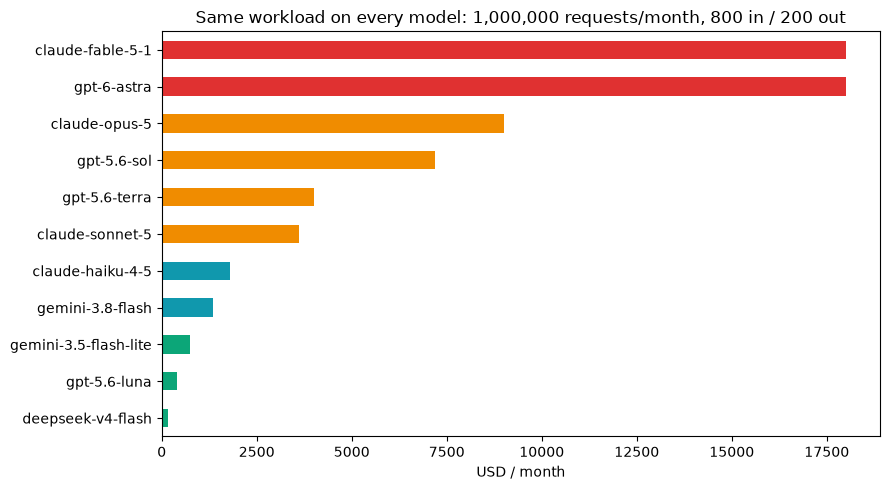

In [4]:
REQUESTS, T_IN, T_OUT = 1_000_000, 800, 200

rows = [dict(model=m, monthly=cost(m, T_IN * REQUESTS, T_OUT * REQUESTS)) for m in PRICES]
df = pd.DataFrame(rows).sort_values("monthly").reset_index(drop=True)
df["x_vs_cheapest"] = (df.monthly / df.monthly.min()).round(1)
show(df.style.format({"monthly": "${:,.0f}"}))

print(f"\nCheapest {usd(df.monthly.min())}/month, most expensive {usd(df.monthly.max())}/month "
      f"({df.x_vs_cheapest.max():.0f}x)")

# colour the bars by price band so the tiers are easy to see
band = pd.cut(df.x_vs_cheapest, [0, 5, 20, 60, float("inf")], labels=False)
palette = ["#0CA678", "#1098AD", "#F08C00", "#E03131"]
ax = df.plot.barh(x="model", y="monthly", legend=False, figsize=(9, 5),
                  color=[palette[b] for b in band])
ax.set_xlabel("USD / month")
ax.set_ylabel("")
ax.set_title(f"Same workload on every model: {REQUESTS:,} requests/month, {T_IN} in / {T_OUT} out")
plt.tight_layout()
plt.show()


**Reading the output.** For the same workload, the bill goes from about \$168 a month to about \$18,000 a month, roughly 107×. That's the biggest single number in this course, and it's why model choice is the first thing to question when a bill looks high.

One caveat before you take this to anyone: these models aren't equally capable. The cheap ones will get some tasks wrong that the expensive ones get right. The point isn't that everyone should use the cheapest model. The point is that "use the best model for everything" is a very expensive default, and a lot of everyday traffic (extraction, classification, short answers) doesn't need it. Lesson 6 is about deciding which requests can go to a cheaper model without hurting quality.


\
---
## 3. A forecast that survives contact with production

A price per million tokens isn't a forecast. Here's the formula we'll use instead:

$$
\text{Monthly \$} = \text{Requests} \times \frac{\text{fresh\_in} \cdot P_{in} + \text{cached\_in} \cdot P_{cache} + \text{out} \cdot P_{out}}{10^6} \times M_{context} \times (1 + R_{retry})
$$

where the token counts are *per completed task*, not per API call. That difference matters most for agents.

When an agent takes several steps (call a tool, read the result, decide what to do next), each step is a new API call, and each call re-sends everything so far: the system prompt, the conversation, and every earlier tool result. So input grows with each step. `coursekit.forecast()` uses a simple model of this. It assumes each step adds about as much context as the original prompt, so a 5-step task reads 1 + 2 + 3 + 4 + 5 = 15 times the original input, while output grows only 5 times. That's why agent bills are mostly input bills.

The other two knobs:

- `context_multiplier` stands in for long-context pricing tiers. Some providers charge more per token once a prompt passes a size threshold. Here we apply it to the whole call, which is a rough approximation.
- `retry_rate` covers failed tool calls, regenerations, and timeouts: work you pay for that the user never sees.

Two simplifications to be aware of: `forecast()` ignores the one-off cost of *writing* the cache, and it assumes every step is the same size. Both are fine for planning. Neither is fine for an invoice reconciliation.

We'll run four scenarios on the same 1M-requests-a-month product and change one thing at a time.

> **In class:** ask someone for their real monthly volume and average prompt size and put those into scenario A.


### Scenario A: the chat assistant in the original business case

One turn per request, mid-tier model, no caching, no retries.


In [5]:
forecast(MODELS.mid, 1_000_000, 800, 200);


  model            claude-sonnet-5
  input tokens     800  (800 fresh / 0 cached)
  output tokens    200
  cost per task    $0.003600
  MONTHLY          $3,600.00


### Scenario B: the same feature six months later, now an agent

The product looks the same to the user, but each request now runs five tool-calling steps, and 8% of them get retried. Compare the monthly figure with scenario A.


In [6]:
forecast(MODELS.mid, 1_000_000, 800, 200, agent_steps=5, retry_rate=0.08);


  model            claude-sonnet-5
  input tokens     12,000  (12,000 fresh / 0 cached)
  output tokens    1,000
  cost per task    $0.0367
  MONTHLY          $36,720.00


That's roughly a tenfold jump, and nobody changed the price list. Input went from 800 tokens to 12,000 per task, output from 200 to 1,000, and then the retries went on top.

### Scenario C: same agent, with prompt caching

Now suppose 80% of that re-read input is served from the provider's prompt cache (Lesson 2 covers how). Cached input is billed at about a tenth of the normal input price. Output can't be cached.


In [7]:
forecast(MODELS.mid, 1_000_000, 800, 200,
         agent_steps=5, retry_rate=0.08, cache_hit_rate=0.80);


  model            claude-sonnet-5
  input tokens     12,000  (2,400 fresh / 9,600 cached)
  output tokens    1,000
  cost per task    $0.0181
  MONTHLY          $18,057.60


Caching roughly halves the bill here. That's a big win, but it doesn't take you back to scenario A, because the output tokens and the uncached 20% of input are still billed at full price.

### Scenario D: send most of the traffic to a cheaper model

Finally, suppose we route 70% of tasks to the floor model, keep 20% on mid, and send the hardest 10% to the frontier model. The split is an assumption here. In Lesson 6 you'll measure what split your own traffic can support.


In [8]:
mix = {MODELS.floor: 0.70, MODELS.mid: 0.20, MODELS.frontier: 0.10}
blended = 0.0
for m, share in mix.items():
    monthly, _ = forecast(m, 1_000_000, 800, 200, agent_steps=5,
                          retry_rate=0.08, cache_hit_rate=0.80, verbose=False)
    print(f"  {share:>4.0%} on {m:<24} {usd(monthly * share):>12}/month")
    blended += share * monthly
print(f"Blended monthly cost with a 70/20/10 split: {usd(blended)}")


   70% on claude-haiku-4-5            $6,320.16/month
   20% on claude-sonnet-5             $3,611.52/month
   10% on claude-opus-5               $4,514.40/month
Blended monthly cost with a 70/20/10 split: $14,446.08


The saving here is smaller than you might expect. Look at the per-model lines: the 10% of traffic on the frontier model costs almost as much as the 70% on the floor model. Routing only pays off when the expensive tier is kept for the requests that really need it. Pushing a bit more traffic up "just to be safe" eats the saving fast.


---
## 4. Give finance a range, not a number

Agent costs vary a lot from run to run: the same task can take three steps one time and nine the next. So a single forecast figure is almost guaranteed to be wrong. It's more honest, and more useful, to give a best case, a base case, and a worst case, and to say which assumptions produce each one.

The table below uses the same volume for all three. The best case uses the floor model with good caching. The base case uses mid-tier with moderate caching. The worst case uses mid-tier, no caching, long agent runs, and long-context pricing.


In [9]:
scenarios = {
    "best  (floor model, cached, short runs)": dict(model=MODELS.floor, agent_steps=3,
                                                    cache_hit_rate=0.85, retry_rate=0.03),
    "base  (mid model, some caching)":         dict(model=MODELS.mid, agent_steps=5,
                                                    cache_hit_rate=0.60, retry_rate=0.08),
    "worst (mid model, no cache, long runs)":  dict(model=MODELS.mid, agent_steps=9,
                                                    cache_hit_rate=0.0, retry_rate=0.20,
                                                    context_multiplier=2.0),
}
out = []
for name, kw in scenarios.items():
    kw = dict(kw)
    m = kw.pop("model")
    monthly, per_task = forecast(m, 1_000_000, 800, 200, verbose=False, **kw)
    out.append(dict(scenario=name, model=m, cost_per_task=per_task, monthly=monthly))
df = pd.DataFrame(out)
show(df.style.format({"cost_per_task": "${:,.4f}", "monthly": "${:,.0f}"}))
print(f"\nWorst case is {df.monthly.max() / df.monthly.min():.0f}x the best case.")


,scenario,model,cost_per_task,monthly
0,"best (floor model, cached, short runs)",claude-haiku-4-5,$0.0043,"$4,252"
1,"base (mid model, some caching)",claude-sonnet-5,$0.0227,"$22,723"
2,"worst (mid model, no cache, long runs)",claude-sonnet-5,$0.2160,"$216,000"



Worst case is 51x the best case.


The gap between best and worst is wide, often a factor of 50 or more. That width is the useful information. It tells whoever approves the budget which assumptions are worth watching (steps per task, cache hit rate, retry rate) and gives you something to check the first real invoices against.


---
## 5. One real call, and the usage object

Everything so far has been arithmetic. Now we make one real API call and look at what the provider says we used. The usage object that comes back with every response is what you're billed on, so it's the number to trust.

Before the call we count the prompt three ways: with tiktoken, with the provider's own counter (Anthropic has a free `count_tokens` endpoint; for OpenAI, tiktoken *is* the provider's tokenizer), and then the billed `input_tokens` from the response. Expect the billed number to be a bit higher than the raw prompt count, because the API wraps your message in some formatting tokens.

If you're offline, this cell tells you so and skips the comparison.


In [10]:
PROMPT = "In two sentences: why are output tokens priced higher than input tokens?"

print(f"tiktoken estimate        {ntok(PROMPT):>5} tokens")
n, how = vendor_tokens(PROMPT)
print(f"provider's own count     {n if n is not None else '-':>5} tokens   ({how})")

r = complete(PROMPT, model=MODELS.mid, max_tokens=200, label="live round trip")
if r.fallback:
    print("\nNo live answer (offline or the call failed), so there is nothing to compare.")
else:
    print(f"billed input             {r.fresh_input + r.cache_read + r.cache_write:>5} tokens")
    print(f"billed output            {r.output_tokens:>5} tokens"
          + (f"  (of which {r.reasoning_tokens} hidden reasoning)" if r.reasoning_tokens else ""))
    print(f"cost of this call        {usd(r.usd)}")
    print("\nThe model's answer:\n")
    print(r.text)


tiktoken estimate           14 tokens


provider's own count        28 tokens   (anthropic count_tokens (includes message framing))


live round trip                               $0.001476   in=28      out=142    cw=0       cr=0       
billed input                28 tokens
billed output              142 tokens
cost of this call        $0.001476

The model's answer:

Output tokens require the model to perform sequential autoregressive generation—computing a full forward pass for each new token while the previous ones must already be processed—making generation computationally slower and more resource-intensive than simply encoding a prompt. Additionally, input tokens can often be processed in parallel and cached (e.g., via KV caching for repeated context), while output tokens cannot be parallelized in the same way, driving up the cost per token for generation.


If you ran this against Anthropic, you'll probably see the provider count come out above the tiktoken estimate. That's the tokenizer difference from section 1. Either way, the habit to take away is this: estimate with a tokenizer when you're planning, but reconcile with the usage object once you're live. Every later lesson reads its numbers from the usage object for exactly this reason.


In [11]:
ledger()



TOTAL SPENT IN THIS NOTEBOOK: $0.001476


,label,model,input,output,cache_write,cache_read,usd,note
0,live round trip,claude-sonnet-5,28,142,0,0,0.001476,


---
## What to take away

- The way you write a prompt changes its token count, and IDs, JSON, and boilerplate are more expensive than they look. Tidying prompts is the cheapest optimisation you'll ever make.
- Model choice is the biggest single lever: about 107× between the cheapest and dearest model on this rate card, for the same workload.
- Agents multiply input, because every step re-reads the context so far. Forecast per completed task, not per call.
- Caching removes a large share of input cost, but it can't touch output, so it only fixes part of the problem.
- Give a best / base / worst range, and say which assumptions drive each end.


### Check yourself

**1. A 40-token system prompt is sent on every call. You add a 30-token legal disclaimer. At 2 million calls a month on a model charging $2 per million input tokens, what does the disclaimer cost per month?**

<details><summary>Show answer</summary>

30 tokens × 2,000,000 calls = 60 million tokens a month. At \$2 per million that's **\$120 a month**, for a sentence nobody reads. The same arithmetic applies to any fixed text in a prompt.

</details>

**2. An agent takes 4 steps and the original prompt is 1,000 tokens. Using the simple model in `forecast()`, how many input tokens does one task read?**

<details><summary>Show answer</summary>

1,000 × (1 + 2 + 3 + 4) = **10,000 input tokens**: ten times the prompt, not four.

</details>

**3. Your cache hit rate goes from 0% to 90%. Why doesn't your bill fall by anything like 90%?**

<details><summary>Show answer</summary>

Caching only discounts the cached share of *input* (and cached input still costs about 10% of the normal price). Output tokens are never cached, and output is the more expensive side, so the saving on the total bill is much smaller than the headline input discount.

</details>


### Try it on your own work

Pick one prompt you use in production. Count its tokens as it is now, then after cutting it down to the essentials, then with your real IDs and field names in it. Price all three versions on the floor, mid, and frontier models at your real monthly volume. That usually takes about fifteen minutes, and it's a much better starting point for a cost discussion than a vendor's price sheet.
